In [2]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
import sys
import time

In [3]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=200, facecolor='white')

In [4]:
import sys
sys.path.append('../src/resolute')
import resolute as rs

In [6]:
adata = sc.read_h5ad("../../tests/datasets/paul15/processed_data.h5ad")

In [7]:
adata

AnnData object with n_obs × n_vars = 2730 × 685
    obs: 'paul15_clusters', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'iroot', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [8]:
len(adata.obs['paul15_clusters'].unique())

19

In [9]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)

computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50


/opt/conda/envs/spatialdata/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)


--- Running CALINSKI Scoring ---
Performing 19 parallel clusterings, using 19/64 CPU cores


Optimizing CALINSKI: 100%|██████████| 19/19 [00:05<00:00,  3.62it/s]


Detected 5 local minima at resolutions: [0.30000000000000004, 0.5, 0.7000000000000001, 1.4000000000000001, 1.7000000000000002]
Suggested Resolution (Deepest Dip): 0.50

--- Running Bootstrap Stability Analysis (optimized) ---
Performing 19 parallel bootstraps (50 iterations each), using 19/64 CPU cores


Evaluating Stability: 100%|██████████| 19/19 [00:27<00:00,  1.44s/it]


Detected 5 stable local maxima at resolutions: [0.2, 0.4, 0.7000000000000001, 1.5000000000000002, 1.7000000000000002]
Suggested Stability Resolution (Highest Peak): 0.20


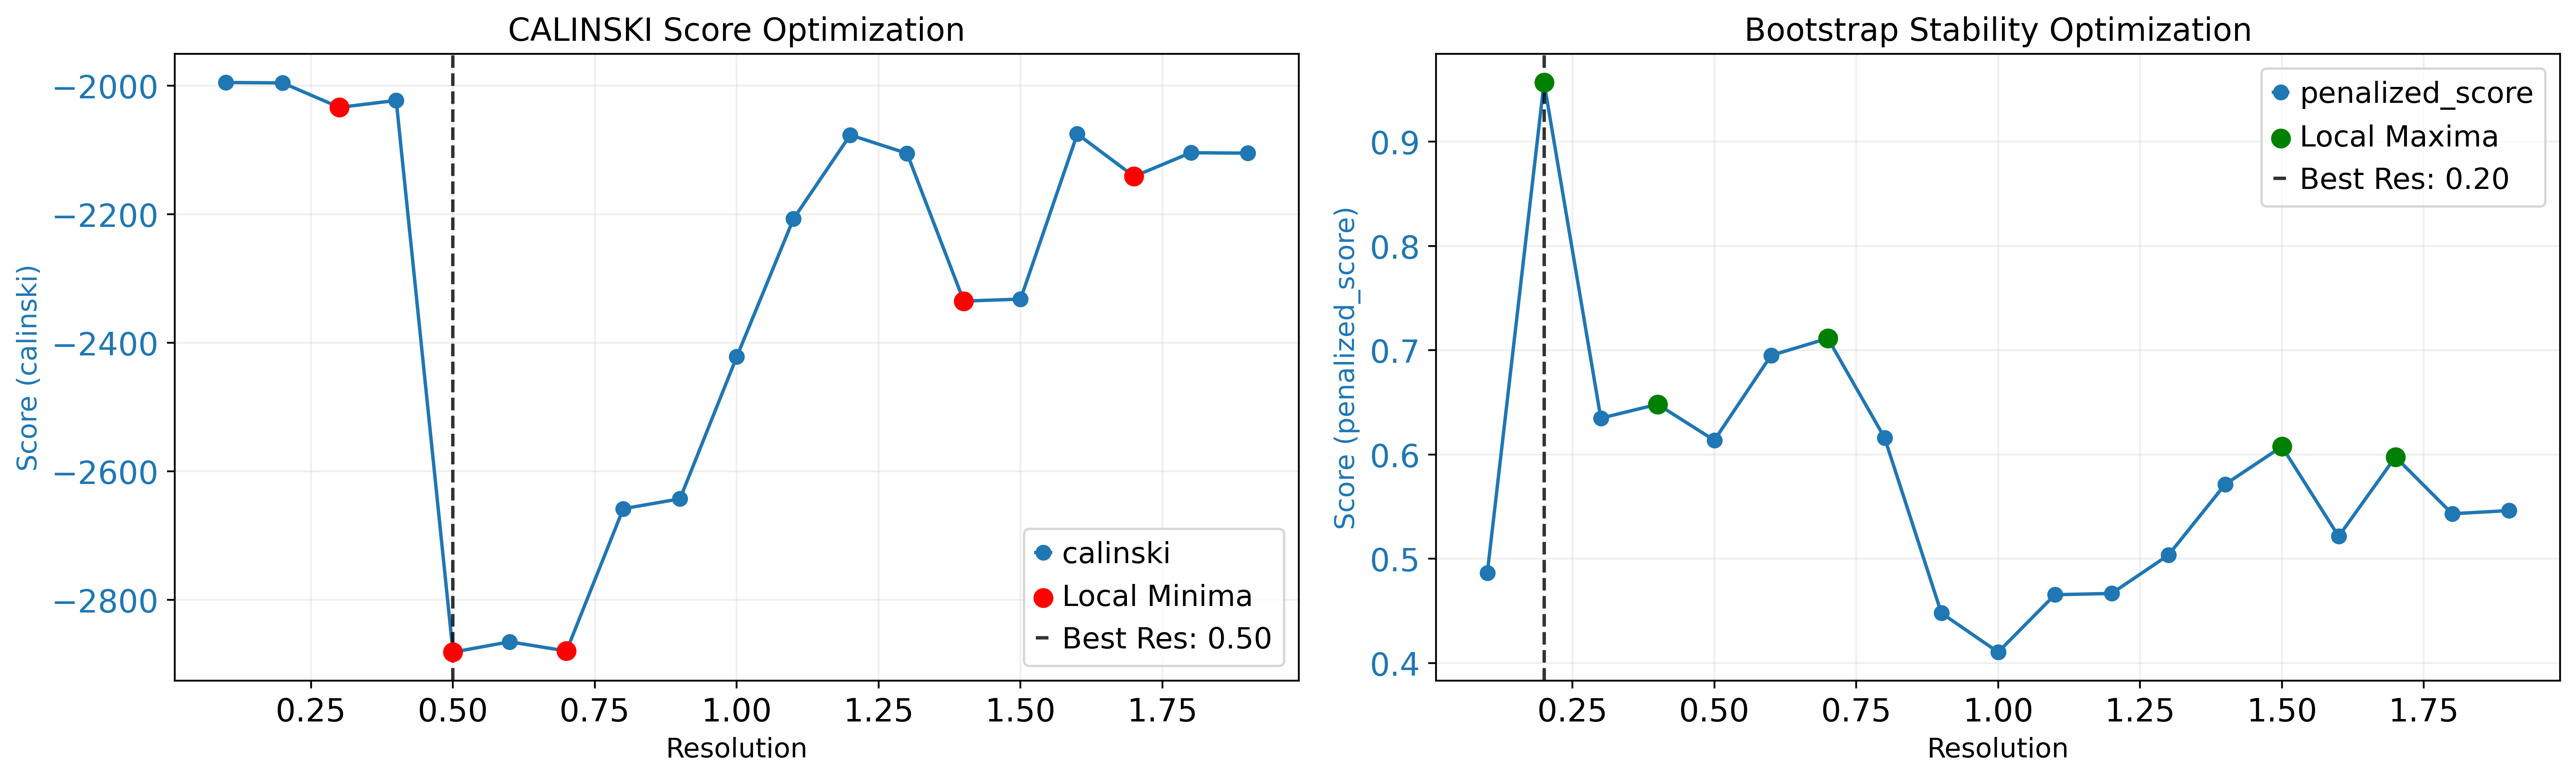


Optimization Summary for CALINSKI & Stability
-----------------------------------------------------------------------------------------------------
Resolution | CALINSKI Score   | Clusters (clustering_score) | Stability Score  | Clusters (Stability)
-----------------------------------------------------------------------------------------------------
0.1        | -1994.9457       | 4                           | 0.4863           | 4                   
0.2        | -1995.6192       | 4                           | 0.9567           | 4                   
0.3        | -2033.6976       | 5                           | 0.6348           | 5                   
0.4        | -2022.8138       | 7                           | 0.6482           | 7                   
0.5        | -2880.9934       | 7                           | 0.6137           | 7                   
0.6        | -2864.9114       | 7                           | 0.6950           | 7                   
0.7        | -2879.2637       | 7  

In [10]:
results = rs.run_resolute(
    adata, 
    score_value='calinski', 
    use_rep='X_umap', 
    stability_use_rep = 'X_pca',
    compute_stability=True, 
    n_iterations=50
)

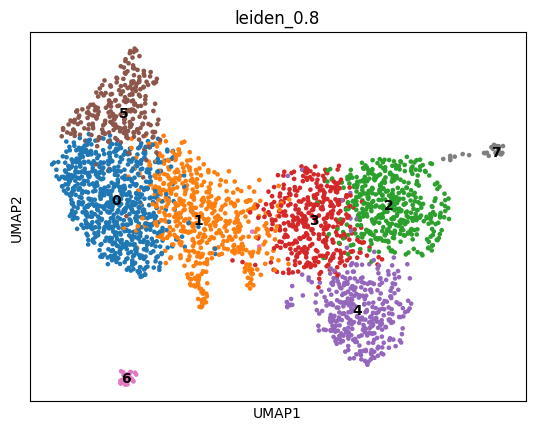

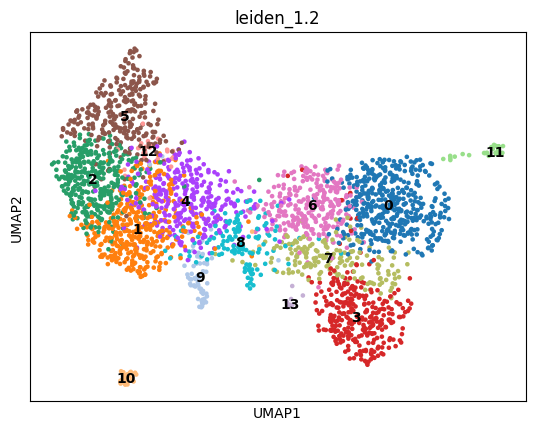

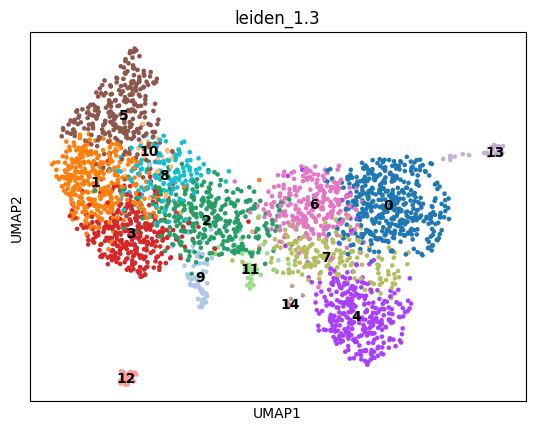

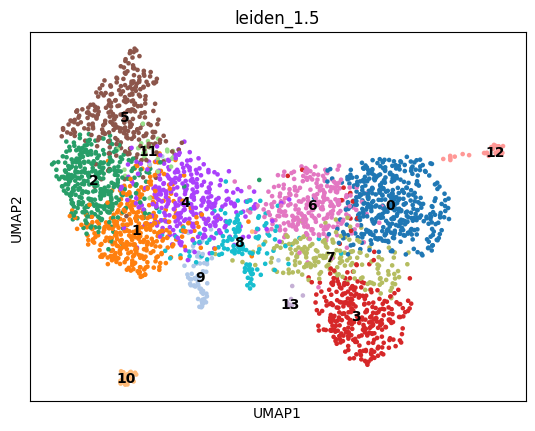

In [19]:
for res in [0.8, 1.2, 1.3, 1.5]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")